# Interactive Script (for development purposes only)

In [1]:
!which python

/dss/dsstbyfs02/pr94no/pr94no-dss-0001/drylands/envs/stac2cube/bin/python


## Geometry comparison between two data arrays

In [21]:
def check_geometry_match(existing, lazy):
    # Check if both datasets have 'x' and 'y' coordinates
    for coord in ['x', 'y']:
        if coord not in existing.coords or coord not in lazy.coords:
            raise ValueError(f"Missing spatial coordinate '{coord}' in one of the datasets.")
        
        # Compare coordinate values (assumes coordinates are numpy arrays or similar)
        if not np.array_equal(existing.coords[coord].values, lazy.coords[coord].values):
            raise ValueError("The provided STAC datasets are from different regions and have incompatible spatial grids.")
    return True

In [22]:
check_geometry_match(stac_existing, stac_lazy)

True

In [ ]:
from pystac_client import Client as pystacclient
catalog = pystacclient.open('https://stac.terrabyte.lrz.de/public/api') #https://planetarycomputer.microsoft.com/api/stac/v1
 
# list the IDs of all STAC catalog collections
for collection in catalog.get_all_collections():
    print(collection.id)

In [27]:
from pystac_client import Client as pystacclient
catalog_url = 'https://planetarycomputer.microsoft.com/api/stac/v1'
catalog = pystacclient.open(catalog_url)

bbox_list= [100.767417,45.208589,100.783210,45.215543]
collection = 'landsat-c2-l2'
bbox = bbox_list
start = '2022-07-20'
end = '2023-09-30'
results = catalog.search(
    bbox = bbox,
    collections=[collection],
    datetime=[start, end]
)
items = results.item_collection()
print("%s items found" % len(items))

181 items found


In [2]:
items

In [28]:
sample_item = items[-1]

In [40]:
sample_item

<Item id=LC09_L2SP_135028_20220720_02_T1>

In [56]:
sample_item.assets["qa_pixel"]

<Asset href=https://landsateuwest.blob.core.windows.net/landsat-c2/level-2/standard/oli-tirs/2022/135/028/LC09_L2SP_135028_20220720_20220723_02_T1/LC09_L2SP_135028_20220720_20220723_02_T1_QA_PIXEL.TIF>

In [7]:
sample_item.properties["sat:orbit_state"]

'descending'

In [51]:
import geopandas as gpd
#stac_json = items
gdf = gpd.GeoDataFrame.from_features(items, "epsg:4326")

In [ ]:
gdf

In [ ]:
#gdf = gpd.GeoDataFrame.from_features(stac_json, "epsg:4326")

# Compute granule id from components
gdf["granule"] = (
    gdf["mgrs:utm_zone"].apply(lambda x: f"{x:02d}")
    + gdf["mgrs:latitude_band"]
    + gdf["mgrs:grid_square"]
)

In [ ]:
gdf["granule"]

In [47]:
unique_values = gdf["granule"].unique()
unique_values

array(['47TPL'], dtype=object)

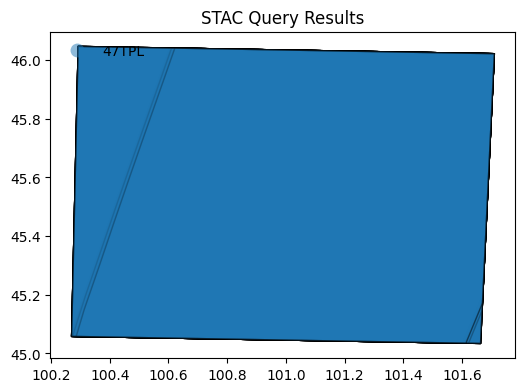

In [48]:
fig = gdf.plot(
    "granule",
    edgecolor="black",
    categorical=True,
    aspect="equal",
    alpha=0.5,
    figsize=(6, 12),
    legend=True,
    legend_kwds={"loc": "upper left", "frameon": False, "ncol": 1},
)
_ = fig.set_title("STAC Query Results")

## Native Cloud Masking

In [1]:
from stac2cube import get_stac_layers
from stac2cube import interactive_time_view

In [2]:
mission = "l_oli"                              # both name and allias work. Can not be None!
polygon = "./polygons/test.gpkg"            # if not available, try optional cell below
resolution = 30                             # if None -> default_resolution
daterange = ["2024-04-01", "2024-04-30"]    # if None -> every available date
bands = ["blue", "green", "red", "nir",]    # if None -> all bands of the relevant mission, but also SCL
max_cc = 100                                # 0-100, if None -> 100
clip_raster = False                         # if None -> False
cloud_masking = True                       # if None -> False
indices = ["ndvi", "ndwi"]                  # if None -> no indices
output = None                               # Will return lazy! To export, replace with path to netcdf.
stats = None                                # if None -> no stats
aggregator = None                           # if None -> no aggregation
animation = False                           # if None -> no animation

In [3]:
stac = get_stac_layers(mission=mission, polygon=polygon, resolution=resolution, 
                            daterange=daterange, bands=bands, max_cc=max_cc, 
                            clip_raster=clip_raster, cloud_masking=cloud_masking, indices=indices, 
                            output=output, aggregator=aggregator, stats=stats,
                            animation=animation)

In [11]:
stac

<xarray.Dataset> Size: 683kB
Dimensions:      (time: 3, y: 83, x: 171)
Coordinates:
  * y            (y) float64 664B 4.547e+06 4.547e+06 ... 4.544e+06 4.544e+06
  * x            (x) float64 1kB 6.67e+05 6.671e+05 ... 6.721e+05 6.721e+05
    spatial_ref  int32 4B 32635
  * time         (time) datetime64[ns] 24B 2024-04-07T08:45:00.128276 ... 202...
Data variables:
    blue         (time, y, x) float32 170kB dask.array<chunksize=(1, 83, 171), meta=np.ndarray>
    green        (time, y, x) float32 170kB dask.array<chunksize=(1, 83, 171), meta=np.ndarray>
    red          (time, y, x) float32 170kB dask.array<chunksize=(1, 83, 171), meta=np.ndarray>
    nir          (time, y, x) float32 170kB dask.array<chunksize=(1, 83, 171), meta=np.ndarray>

In [62]:
interactive_time_view(stac=stac, display_mode='rgb', widget_type='slider')

interactive(children=(IntSlider(value=0, description='Time', layout=Layout(width='800px'), max=2), Output()), …

In [5]:
interactive_time_view(stac=stac, display_mode='rgb', widget_type='slider')

interactive(children=(IntSlider(value=0, description='Time', layout=Layout(width='800px'), max=11), Output()),…

In [16]:
from timeit import timeit

In [17]:
iteration= 10

t = timeit(lambda: get_stac_layers(
    mission=mission,
    polygon=polygon,
    resolution=resolution,
    daterange=daterange,
    bands=bands,
    max_cc=max_cc,
    clip_raster=clip_raster,
    cloud_masking=cloud_masking,
    indices=indices,
    output=output,
    aggregator=aggregator,
    stats=stats,
    animation=animation
), number=iteration)

print("Total time for 10 runs:", t)
print("Average time per run:", t/iteration)

<xarray.DataArray 'Spectral_Temporal_Stack' (time: 37, band: 6, y: 247, x: 511)> Size: 112MB
dask.array<transpose, shape=(37, 6, 247, 511), dtype=float32, chunksize=(1, 1, 247, 511), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 2kB 4.547e+06 4.547e+06 ... 4.544e+06 4.544e+06
  * x            (x) float64 4kB 6.67e+05 6.67e+05 ... 6.721e+05 6.721e+05
  * band         (band) <U5 120B 'blue' 'green' 'red' 'nir' 'ndvi' 'ndwi'
  * time         (time) datetime64[ns] 296B 2024-04-01 2024-04-03 ... 2024-06-30
    spatial_ref  int64 8B 0
Attributes:
    indices:         ['ndvi', 'ndwi']
    spectral_bands:  ['blue', 'green', 'red', 'nir']
    mission:         sentinel_2_l2a
    tile_id:         ['35TPF']
    bbox:            [28.98752355404842, 41.03150270425637, 29.04759458831022...
    crs:             WGS 84 / UTM zone 35N
    transform:       | 10.00, 0.00, 667020.00|\n| 0.00,-10.00, 4546620.00|\n|...
<xarray.DataArray 'Spectral_Temporal_Stack' (time: 37, band: 6, y: 24

In [ ]:
import pystac

# Load separate STAC catalogs
catalog_tm = pystac.read_file("https://stac.terrabyte.lrz.de/public/api/collections/landsat-tm-c2-l2")
#catalog_etm = pystac.read_file("path/to/landsat_etm_catalog.json")
#catalog_oli = pystac.read_file("path/to/landsat_oli_catalog.json")


In [16]:
import xarray as xr
stac_existing = xr.open_dataset("./results/test_cloud.nc")
if "Spectral_Temporal_Stack" in list(stac_existing.data_vars):
    print("yeee")

In [17]:
stac_existing

<xarray.Dataset> Size: 1MB
Dimensions:      (time: 2, y: 247, x: 511, band: 4)
Coordinates:
  * time         (time) datetime64[ns] 16B 2024-04-06 2024-04-08
  * y            (y) float64 2kB 4.547e+06 4.547e+06 ... 4.544e+06 4.544e+06
  * x            (x) float64 4kB 6.67e+05 6.67e+05 ... 6.721e+05 6.721e+05
  * band         (band) <U13 208B 'cloud_prob' ... 'cloud_mask_90'
Data variables:
    spatial_ref  int64 8B ...
    Cloud_Stack  (time, band, y, x) uint8 1MB ...

In [2]:
import pystac_client
import planetary_computer
import odc.stac
import matplotlib.pyplot as plt

from pystac.extensions.eo import EOExtension as eo

In [3]:
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

In [5]:
bbox_of_interest = [-122.2751, 47.5469, -121.9613, 47.7458]
time_of_interest = "2012-01-01/2019-12-31"

search = catalog.search(
    collections=["landsat-c2-l2"],
    bbox=bbox_of_interest,
    datetime=time_of_interest,
    query={"eo:cloud_cover": {"lt": 10}},
)

items = search.item_collection()
print(f"Returned {len(items)} Items")



Returned 91 Items


In [1]:
import numpy as np
import xarray as xr
from pystac_client import Client as pystacclient
from odc.stac import stac_load
import planetary_computer

# --- Query Parameters for Landsat ---
catalog_url = 'https://planetarycomputer.microsoft.com/api/stac/v1'
catalog = pystacclient.open(catalog_url)
catalog = pystacclient.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

bbox = [28.846836090087894, 40.99285619545553, 29.36079025268555, 41.09642951747954]
collection = 'landsat-c2-l2'
start = "2023-01-01"
end = "2023-01-31"

results = catalog.search(
    bbox=bbox,
    collections=[collection],
    datetime=f'{start}/{end}'
)
items = results.item_collection()

# --- Load Data using odc_load ---
# Here we specify the measurements we want to load.
# For Landsat-C2-L2, we're loading three reflectance bands (red, green, blue)
# and the QA band 'qa_pixel' which is used for cloud masking.
# Adjust the measurement names if needed according to the product spec.


stac = stac_load(
        items,
        bands=['red', 'green', 'blue', 'qa_pixel'],
        crs=32635,
        resolution=30,
        resampling="bilinear",
        chunks={},
        groupby="solar_day",
        bbox=bbox,
    )


In [2]:
stac

<xarray.Dataset> Size: 34MB
Dimensions:      (y: 419, x: 1450, time: 7)
Coordinates:
  * y            (y) float64 3kB 4.552e+06 4.552e+06 ... 4.54e+06 4.54e+06
  * x            (x) float64 12kB 6.551e+05 6.551e+05 ... 6.985e+05 6.986e+05
    spatial_ref  int32 4B 32635
  * time         (time) datetime64[ns] 56B 2023-01-07T08:45:50.926221 ... 202...
Data variables:
    red          (time, y, x) uint16 9MB dask.array<chunksize=(1, 419, 1450), meta=np.ndarray>
    green        (time, y, x) uint16 9MB dask.array<chunksize=(1, 419, 1450), meta=np.ndarray>
    blue         (time, y, x) uint16 9MB dask.array<chunksize=(1, 419, 1450), meta=np.ndarray>
    qa_pixel     (time, y, x) uint16 9MB dask.array<chunksize=(1, 419, 1450), meta=np.ndarray>

In [122]:
getattr(stac, "qa_pixel")

<xarray.DataArray 'qa_pixel' (time: 7, y: 419, x: 1450)> Size: 9MB
dask.array<qa_pixel, shape=(7, 419, 1450), dtype=uint16, chunksize=(1, 419, 1450), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 3kB 4.552e+06 4.552e+06 ... 4.54e+06 4.54e+06
  * x            (x) float64 12kB 6.551e+05 6.551e+05 ... 6.985e+05 6.986e+05
    spatial_ref  int32 4B 32635
  * time         (time) datetime64[ns] 56B 2023-01-07T08:45:50.926221 ... 202...
Attributes:
    nodata:   1

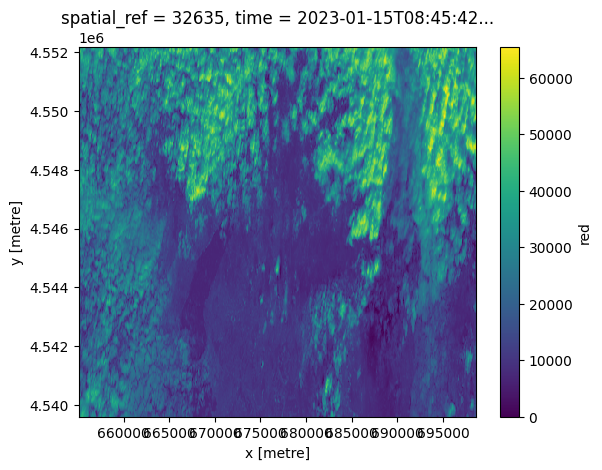

In [37]:
stac.red[2].plot()

In [45]:
mask_dilated = ((stac.qa_pixel >> 1) & 1).astype(bool)   # dilated_cloud (bit offset 1)
mask_cirrus  = ((stac.qa_pixel >> 2) & 1).astype(bool)    # cirrus (bit offset 2)
mask_cloud   = ((stac.qa_pixel >> 3) & 1).astype(bool)    # cloud (bit offset 3)

# Combine masks: a pixel is considered cloud if any of the three are True.
combined_mask = mask_dilated | mask_cirrus | mask_cloud

In [46]:
stac_masked = stac.where(~cloud_mask)

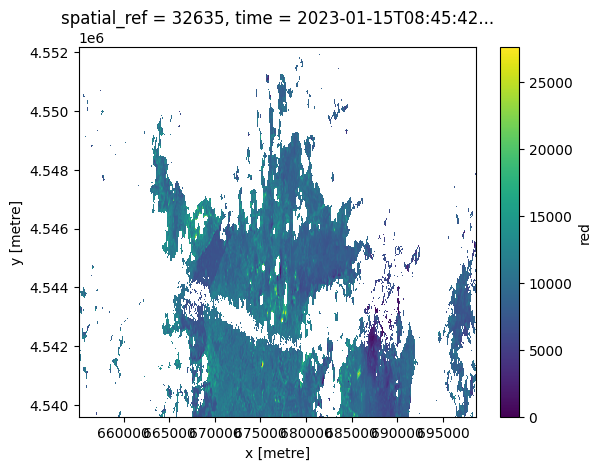

In [50]:
stac_masked.red[2].plot()

In [34]:
cloud_mask = getattr(stac, "qa_pixel")#.isin([1,2,3])
stac_masked = stac.where(~cloud_mask)

In [42]:
cloud_mask = ((stac.qa_pixel >> 3) & 1).astype(bool)

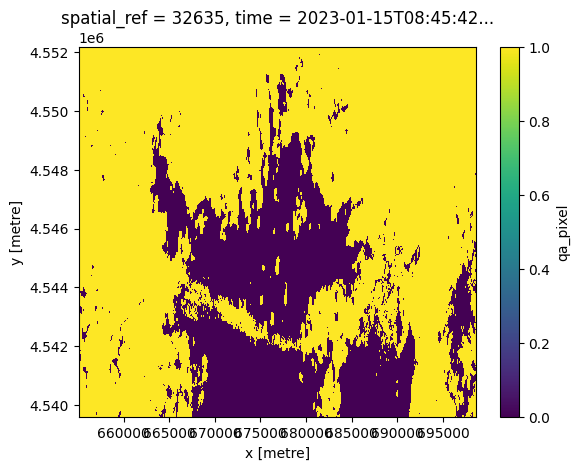

In [43]:
cloud_mask[2].plot()

In [9]:
import xarray as xr
stac_masked = stac.where(~xr.DataArray(cloud_mask, dims=stac.qa_pixel.dims))

In [10]:
stac_masked

<xarray.Dataset> Size: 68MB
Dimensions:      (time: 7, y: 419, x: 1450)
Coordinates:
  * y            (y) float64 3kB 4.552e+06 4.552e+06 ... 4.54e+06 4.54e+06
  * x            (x) float64 12kB 6.551e+05 6.551e+05 ... 6.985e+05 6.986e+05
    spatial_ref  int32 4B 32635
  * time         (time) datetime64[ns] 56B 2023-01-07T08:45:50.926221 ... 202...
Data variables:
    red          (time, y, x) float32 17MB dask.array<chunksize=(1, 419, 1450), meta=np.ndarray>
    green        (time, y, x) float32 17MB dask.array<chunksize=(1, 419, 1450), meta=np.ndarray>
    blue         (time, y, x) float32 17MB dask.array<chunksize=(1, 419, 1450), meta=np.ndarray>
    qa_pixel     (time, y, x) float32 17MB dask.array<chunksize=(1, 419, 1450), meta=np.ndarray>

In [91]:
cloud_mask

<xarray.DataArray 'qa_pixel' (time: 7, y: 419, x: 1450)> Size: 4MB
dask.array<any-aggregate, shape=(7, 419, 1450), dtype=bool, chunksize=(1, 419, 1450), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 3kB 4.552e+06 4.552e+06 ... 4.54e+06 4.54e+06
  * x            (x) float64 12kB 6.551e+05 6.551e+05 ... 6.985e+05 6.986e+05
    spatial_ref  int32 4B 32635
  * time         (time) datetime64[ns] 56B 2023-01-07T08:45:50.926221 ... 202...

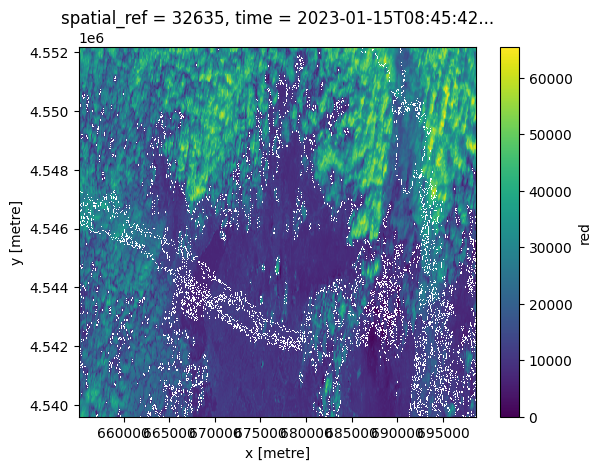

In [11]:
stac_masked.red[2].plot()

In [58]:
stac2

<xarray.DataArray 'qa_pixel' (time: 7, y: 419, x: 1450)> Size: 4MB
dask.array<any-aggregate, shape=(7, 419, 1450), dtype=bool, chunksize=(1, 419, 1450), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 3kB 4.552e+06 4.552e+06 ... 4.54e+06 4.54e+06
  * x            (x) float64 12kB 6.551e+05 6.551e+05 ... 6.985e+05 6.986e+05
    spatial_ref  int32 4B 32635
  * time         (time) datetime64[ns] 56B 2023-01-07T08:45:50.926221 ... 202...

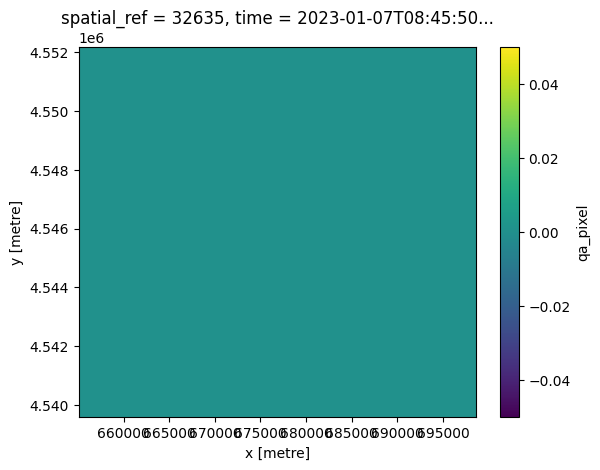

In [64]:
stac2[0].plot()

In [23]:
ds= stac

In [24]:

# --- Apply a Simple Cloud Mask ---
# This example assumes that qa_pixel values 1, 2, 3 indicate clouds.
# In practice, the qa_pixel is bit-packed so you should decode the bits properly.
cloud_mask = ds.qa_pixel.isin([1, 2, 3])
ds_masked = ds.where(~cloud_mask)  # Replace cloud pixels with NaN
ds_masked = ds_masked.drop_vars('qa_pixel')  # Optionally drop the QA band

# --- Output the Result ---
print(ds_masked)

<xarray.Dataset> Size: 51MB
Dimensions:      (time: 7, y: 419, x: 1450)
Coordinates:
  * y            (y) float64 3kB 4.552e+06 4.552e+06 ... 4.54e+06 4.54e+06
  * x            (x) float64 12kB 6.551e+05 6.551e+05 ... 6.985e+05 6.986e+05
    spatial_ref  int32 4B 32635
  * time         (time) datetime64[ns] 56B 2023-01-07T08:45:50.926221 ... 202...
Data variables:
    red          (time, y, x) float32 17MB dask.array<chunksize=(1, 419, 1450), meta=np.ndarray>
    green        (time, y, x) float32 17MB dask.array<chunksize=(1, 419, 1450), meta=np.ndarray>
    blue         (time, y, x) float32 17MB dask.array<chunksize=(1, 419, 1450), meta=np.ndarray>


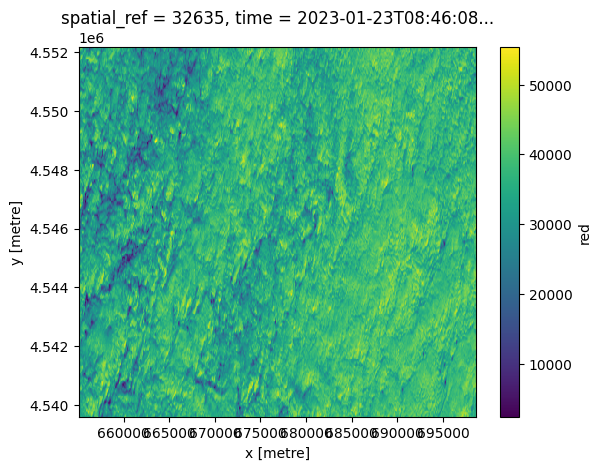

In [31]:
ds_masked.red[4].plot()